In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Read CSV File

df = pd.read_csv('AirQualityUCI.csv')

In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH
0,10-03-2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,10-03-2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,10-03-2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,10-03-2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,10-03-2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [5]:
print(df.columns)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'Wind',
       'PT08.S2(NMHC)', 'Solor.R', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'Ozone', 'Temp', 'RH', 'AH'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   Wind           9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   Solor.R        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  Ozone          9357 non-null   int64  
 12  Temp           9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [7]:
# Check Missing Values

df.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
Wind             0
PT08.S2(NMHC)    0
Solor.R          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
Ozone            0
Temp             0
RH               0
AH               0
dtype: int64

In [8]:
# Fill Missing Values

df = df.fillna(df.mean(numeric_only=True))

In [9]:
# Remove Duplicate Rows

df = df.drop_duplicates()

In [10]:
# Convert Date Column

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [11]:
# Create Year and Month Column

df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

In [12]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH,Year,Month
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578,2004,3
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255,2004,3
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502,2004,3
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867,2004,3
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888,2004,3


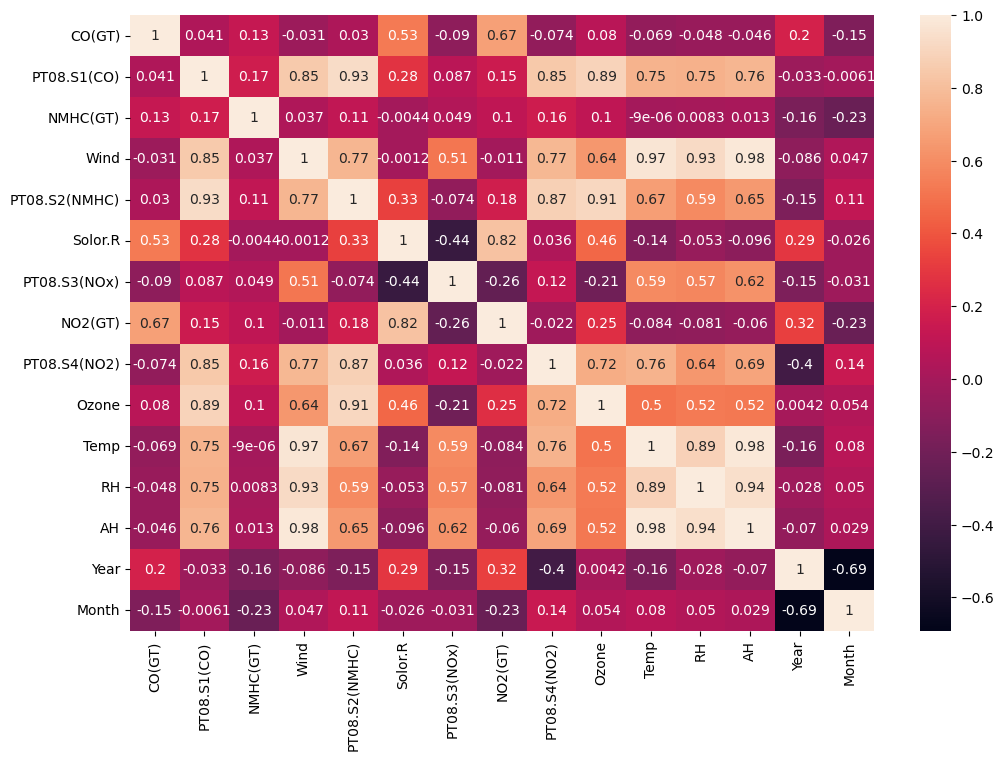

In [13]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

<Axes: xlabel='Month', ylabel='Temp'>

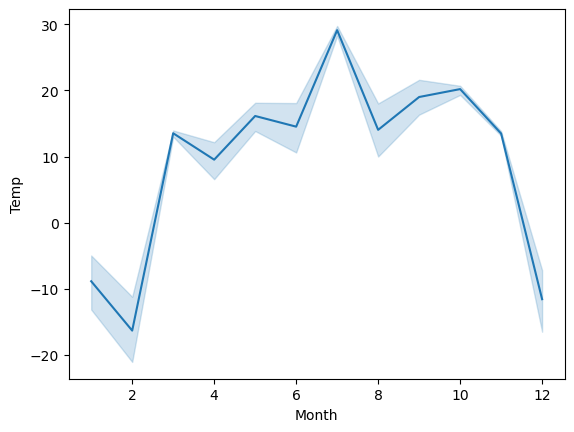

In [14]:
# Line Plot

sns.lineplot(data=df, x='Month', y='Temp')

<Axes: xlabel='Month', ylabel='CO(GT)'>

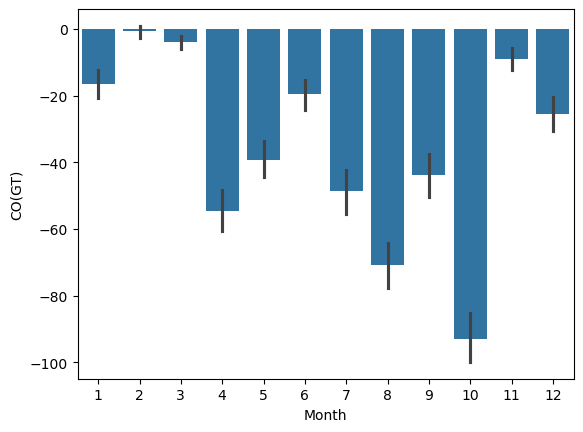

In [15]:
# Bar Plot

sns.barplot(data=df, x='Month', y='CO(GT)')

<Axes: xlabel='NO2(GT)', ylabel='Ozone'>

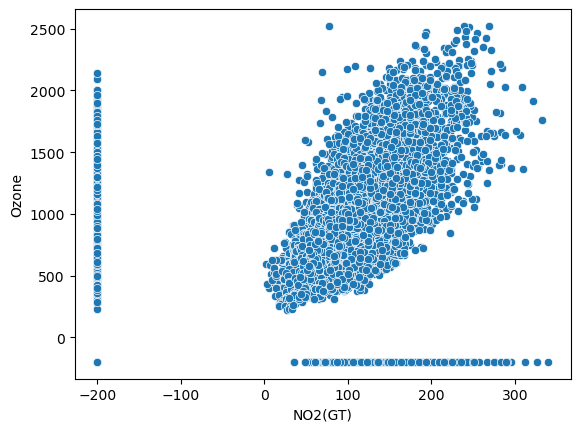

In [16]:
# Scatter Plot

sns.scatterplot(data=df, x='NO2(GT)', y='Ozone')

<Axes: xlabel='Temp'>

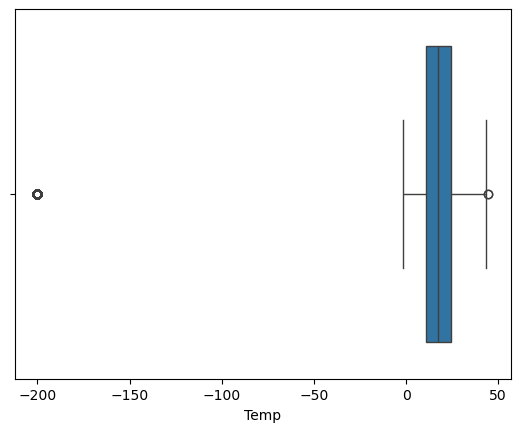

In [17]:
# Box Plot

sns.boxplot(x=df['Temp'])

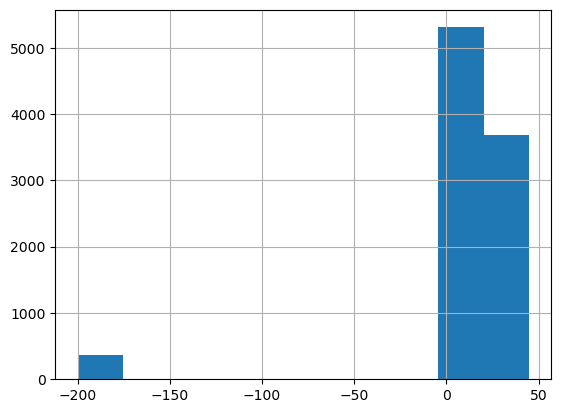

In [18]:
# Histogram

df['Temp'].hist()
plt.show()